# Benchmark Results — Cross Cell Type

compares the 5 benchmark model families (FM PCA d=16, FM/ODE in hybrid_d1e3 AE latent,
FM/ODE in MSE d=512 AE latent) across the three per-cell-type holdout splits
(K562, A549, MCF7). each (model, cell_type) pair is a separately trained run with
its own held-out perturbations. outputs:

- per-(model, cell_type) summary tables
- aggregate across cell types (mean ± std over the 3 splits)
- grouped bar charts per metric


In [1]:
%env PYTORCH_ENABLE_MPS_FALLBACK=1

env: PYTORCH_ENABLE_MPS_FALLBACK=1


In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
from IPython.display import display

from flatcfm.analysis import run_benchmark_suite, validate_run_dirs

RUNS_ROOT = Path("artifacts/runs")

# (family, cell_type) -> experiment_name
MODELS = {
    "FM PCA d=16": {
        "K562": "sciplex_fm_deg_pca_d16",
        "A549": "sciplex_fm_deg_pca_a549_d16",
        "MCF7": "sciplex_fm_deg_pca_mcf7_d16",
    },
    "FM hybrid_d1e3 AE": {
        "K562": "sciplex_fm_deg_ae_latent_hybrid_d1e3_k562",
        "A549": "sciplex_fm_deg_ae_latent_hybrid_d1e3_a549",
        "MCF7": "sciplex_fm_deg_ae_latent_hybrid_d1e3_mcf7",
    },
    "ODE hybrid_d1e3 AE": {
        "K562": "sciplex_ode_deg_ae_latent_hybrid_d1e3_k562",
        "A549": "sciplex_ode_deg_ae_latent_hybrid_d1e3_a549",
        "MCF7": "sciplex_ode_deg_ae_latent_hybrid_d1e3_mcf7",
    },
    "FM MSE d=512 AE": {
        "K562": "sciplex_fm_deg_ae_latent_mse_d512",
        "A549": "sciplex_fm_deg_ae_latent_mse_d512_a549",
        "MCF7": "sciplex_fm_deg_ae_latent_mse_d512_mcf7",
    },
    "ODE MSE d=512 AE": {
        "K562": "sciplex_ode_deg_ae_latent_mse_d512",
        "A549": "sciplex_ode_deg_ae_latent_mse_d512_a549",
        "MCF7": "sciplex_ode_deg_ae_latent_mse_d512_mcf7",
    },
}
CELL_TYPES = ["K562", "A549", "MCF7"]

metrics = ["mean_gene_w1", "w2_squared", "cosine_log_fc", "mmd", "sig_deg_recall"]
metric_lower_is_better = {
    "mean_gene_w1": True,
    "w2_squared": True,
    "cosine_log_fc": False,
    "mmd": True,
    "sig_deg_recall": False,
}
metric_arrow = {m: "\u2193" if low else "\u2191" for m, low in metric_lower_is_better.items()}


In [3]:
# discover which (family, cell_type) runs have predictions available
available = []  # list of (family, cell_type, exp_name)
exp_to_key = {}  # model_name -> (family, cell_type)
missing = []

for family, per_ct in MODELS.items():
    for ct, exp in per_ct.items():
        exp_dir = RUNS_ROOT / exp
        if not exp_dir.is_dir():
            missing.append((family, ct, exp, "no run dir"))
            continue
        subs = sorted(d for d in exp_dir.iterdir() if d.is_dir())
        if not subs:
            missing.append((family, ct, exp, "no run subdir"))
            continue
        if not (subs[-1] / "predictions" / "held_out" / "predictions.h5ad").exists():
            missing.append((family, ct, exp, "no predictions"))
            continue
        available.append((family, ct, exp))
        exp_to_key[exp] = (family, ct)

available_experiments = [a[2] for a in available]
print(f"available: {len(available)} / {sum(len(v) for v in MODELS.values())}")
if missing:
    print("missing:")
    for fam, ct, exp, reason in missing:
        print(f"  - {fam} / {ct}: {reason} ({exp})")

if available_experiments:
    validate_run_dirs(available_experiments)
    print("all available runs compatible")


available: 15 / 15
all available runs compatible


In [ ]:
# benchmark suite over all available runs (cached by prediction fingerprint)
import hashlib

CACHE_DIR = Path("artifacts/benchmark_cross_ct_cache")
CACHE_DIR.mkdir(parents=True, exist_ok=True)


def _predictions_fingerprint(experiments: list[str]) -> str:
    parts = []
    for exp in sorted(experiments):
        subs = sorted(d for d in (RUNS_ROOT / exp).iterdir() if d.is_dir())
        if not subs:
            continue
        pred = subs[-1] / "predictions" / "held_out" / "predictions.h5ad"
        if pred.exists():
            parts.append(f"{pred}:{pred.stat().st_mtime}")
    # include the metric set in the fingerprint so adding a new metric
    # invalidates old caches
    parts.append("metrics=" + ",".join(sorted(metrics)))
    return hashlib.sha256("|".join(parts).encode()).hexdigest()[:12]


cache_key = _predictions_fingerprint(available_experiments)
cache_path = CACHE_DIR / f"per_group_{cache_key}.parquet"

if cache_path.exists():
    per_group = pd.read_parquet(cache_path)
    print(f"loaded cached results ({cache_key})")
else:
    base = run_benchmark_suite(
        {
            "experiments": available_experiments,
            "metrics": ["mean_gene_w1", "w2_squared", "cosine_log_fc", "sig_deg_recall"],
            "group_columns": ["cell_type", "product_dose"],
            "reductions": ["unweighted_mean"],
        }
    )
    pca = run_benchmark_suite(
        {
            "experiments": available_experiments,
            "metrics": ["mmd"],
            "group_columns": ["cell_type", "product_dose"],
            "reductions": ["unweighted_mean"],
            "metric_spaces": [{"name": "train_pca_50", "kind": "train_pca", "pca_n_components": 50}],
        }
    )
    per_group = pd.concat([base["per_group_metrics"], pca["per_group_metrics"]], ignore_index=True)
    per_group.to_parquet(cache_path)
    print(f"saved cached results ({cache_key})")

per_group["family"] = per_group["model_name"].map(lambda m: exp_to_key.get(m, (None, None))[0])
per_group["splitter_ct"] = per_group["model_name"].map(lambda m: exp_to_key.get(m, (None, None))[1])
print(f"per_group rows: {len(per_group)}")


In [5]:
# per-(family, cell_type) summary — mean ± std across perturbation groups (within each CT)
rows = []
for family, ct, exp in available:
    for metric in metrics:
        s = per_group[(per_group["model_name"] == exp) & (per_group["metric_base"] == metric)]
        if s.empty:
            s = per_group[(per_group["model_name"] == exp) & (per_group["metric"] == metric)]
        if s.empty:
            continue
        vals = s["value"].dropna()
        rows.append(
            {
                "family": family,
                "cell_type": ct,
                "metric": metric,
                "mean": vals.mean(),
                "std": vals.std(),
                "n_groups": len(vals),
            }
        )
long_df = pd.DataFrame(rows)

per_ct_tables = {}
for metric in metrics:
    sub = long_df[long_df["metric"] == metric]
    if sub.empty:
        continue
    table = sub.pivot_table(index="family", columns="cell_type", values="mean").round(4)
    arrow = metric_arrow[metric]
    print(f"\n== {metric} ({arrow}) ==")
    display(table[[c for c in CELL_TYPES if c in table.columns]])
    per_ct_tables[metric] = table



== mean_gene_w1 (↓) ==


cell_type,K562,A549,MCF7
family,,,
FM MSE d=512 AE,0.2358,0.2381,0.2362
FM PCA d=16,0.2482,0.2534,0.2455
FM hybrid_d1e3 AE,0.3956,0.3845,0.3402
ODE MSE d=512 AE,0.2260,0.2344,0.2553
ODE hybrid_d1e3 AE,0.3987,0.3896,0.3587



== w2_squared (↓) ==


cell_type,K562,A549,MCF7
family,,,
FM MSE d=512 AE,2164.3680,1960.0736,1765.5773
FM PCA d=16,2134.9046,1953.9966,1754.2773
FM hybrid_d1e3 AE,3001.1433,2608.2711,2187.0159
ODE MSE d=512 AE,2194.2129,1951.0013,1766.4490
ODE hybrid_d1e3 AE,2990.7331,2624.3438,2219.5161



== cosine_log_fc (↑) ==


cell_type,K562,A549,MCF7
family,,,
FM MSE d=512 AE,0.1640,0.2371,0.2215
FM PCA d=16,0.1585,0.2037,0.2204
FM hybrid_d1e3 AE,0.0322,0.1055,0.1219
ODE MSE d=512 AE,0.0988,0.1725,0.1427
ODE hybrid_d1e3 AE,0.0331,0.0871,0.0791



== mmd (↓) ==


cell_type,K562,A549,MCF7
family,,,
FM MSE d=512 AE,0.0532,0.0689,0.0389
FM PCA d=16,0.0598,0.0986,0.0456
FM hybrid_d1e3 AE,0.5275,0.5458,0.4057
ODE MSE d=512 AE,0.0821,0.0955,0.0773
ODE hybrid_d1e3 AE,0.5315,0.5566,0.4607


In [6]:
# aggregate across cell types: mean ± std over the 3 splits per model family
agg_rows = []
for family in MODELS:
    sub = long_df[long_df["family"] == family]
    for metric in metrics:
        m = sub[sub["metric"] == metric]["mean"].dropna()
        if m.empty:
            continue
        agg_rows.append(
            {
                "family": family,
                "metric": metric,
                "ct_mean": m.mean(),
                "ct_std": m.std(),
                "n_cell_types": len(m),
            }
        )
agg_df = pd.DataFrame(agg_rows)

if not agg_df.empty:
    formatted = pd.DataFrame(index=sorted(agg_df["family"].unique()))
    for metric in metrics:
        sub = agg_df[agg_df["metric"] == metric]
        if sub.empty:
            continue
        arrow = metric_arrow[metric]
        col = {}
        for _, r in sub.iterrows():
            col[r["family"]] = f"{r['ct_mean']:.4f} ± {r['ct_std']:.4f} (n={r['n_cell_types']})"
        formatted[f"{metric} ({arrow})"] = formatted.index.map(col.get)

    lower = {m: metric_lower_is_better[m] for m in metrics}
    best = {}
    for metric in metrics:
        sub = agg_df[agg_df["metric"] == metric]
        if sub.empty:
            continue
        if lower[metric]:
            best[metric] = sub.loc[sub["ct_mean"].idxmin(), "family"]
        else:
            best[metric] = sub.loc[sub["ct_mean"].idxmax(), "family"]

    def _highlight(col):
        m = [m for m in metrics if m in col.name]
        if not m:
            return [""] * len(col)
        return ["font-weight: bold" if fam == best.get(m[0]) else "" for fam in col.index]

    display(
        formatted.style.apply(_highlight, axis=0).set_caption(
            "cross-cell-type aggregate: mean ± std across (K562, A549, MCF7) per model family (bold = best)"
        )
    )
else:
    print("no aggregate rows yet")


,mean_gene_w1 (↓),w2_squared (↓),cosine_log_fc (↑),mmd (↓)
FM MSE d=512 AE,0.2367 ± 0.0012 (n=3),1963.3396 ± 199.4154 (n=3),0.2075 ± 0.0385 (n=3),0.0537 ± 0.0150 (n=3)
FM PCA d=16,0.2490 ± 0.0040 (n=3),1947.7262 ± 190.3911 (n=3),0.1942 ± 0.0320 (n=3),0.0680 ± 0.0274 (n=3)
FM hybrid_d1e3 AE,0.3735 ± 0.0293 (n=3),2598.8101 ± 407.1461 (n=3),0.0866 ± 0.0478 (n=3),0.4930 ± 0.0761 (n=3)
ODE MSE d=512 AE,0.2385 ± 0.0151 (n=3),1970.5544 ± 214.5512 (n=3),0.1380 ± 0.0371 (n=3),0.0850 ± 0.0094 (n=3)
ODE hybrid_d1e3 AE,0.3823 ± 0.0210 (n=3),2611.5310 ± 385.7681 (n=3),0.0664 ± 0.0291 (n=3),0.5163 ± 0.0497 (n=3)


In [7]:
# grouped bar chart: one panel per metric, one bar group per model family, colored by cell type
CT_COLORS = {"K562": "#4477AA", "A549": "#EE6677", "MCF7": "#228833"}

for metric in metrics:
    sub = long_df[long_df["metric"] == metric]
    if sub.empty:
        continue
    arrow = metric_arrow[metric]

    fig = px.bar(
        sub,
        x="family",
        y="mean",
        color="cell_type",
        error_y="std",
        barmode="group",
        color_discrete_map=CT_COLORS,
        category_orders={"family": list(MODELS.keys()), "cell_type": CELL_TYPES},
        title=f"{metric} ({arrow}) by model family and cell type",
        labels={"family": "model family", "mean": f"{metric} mean across perturbation groups"},
    )
    fig.update_layout(height=450, width=900, template="plotly_white")
    fig.show()


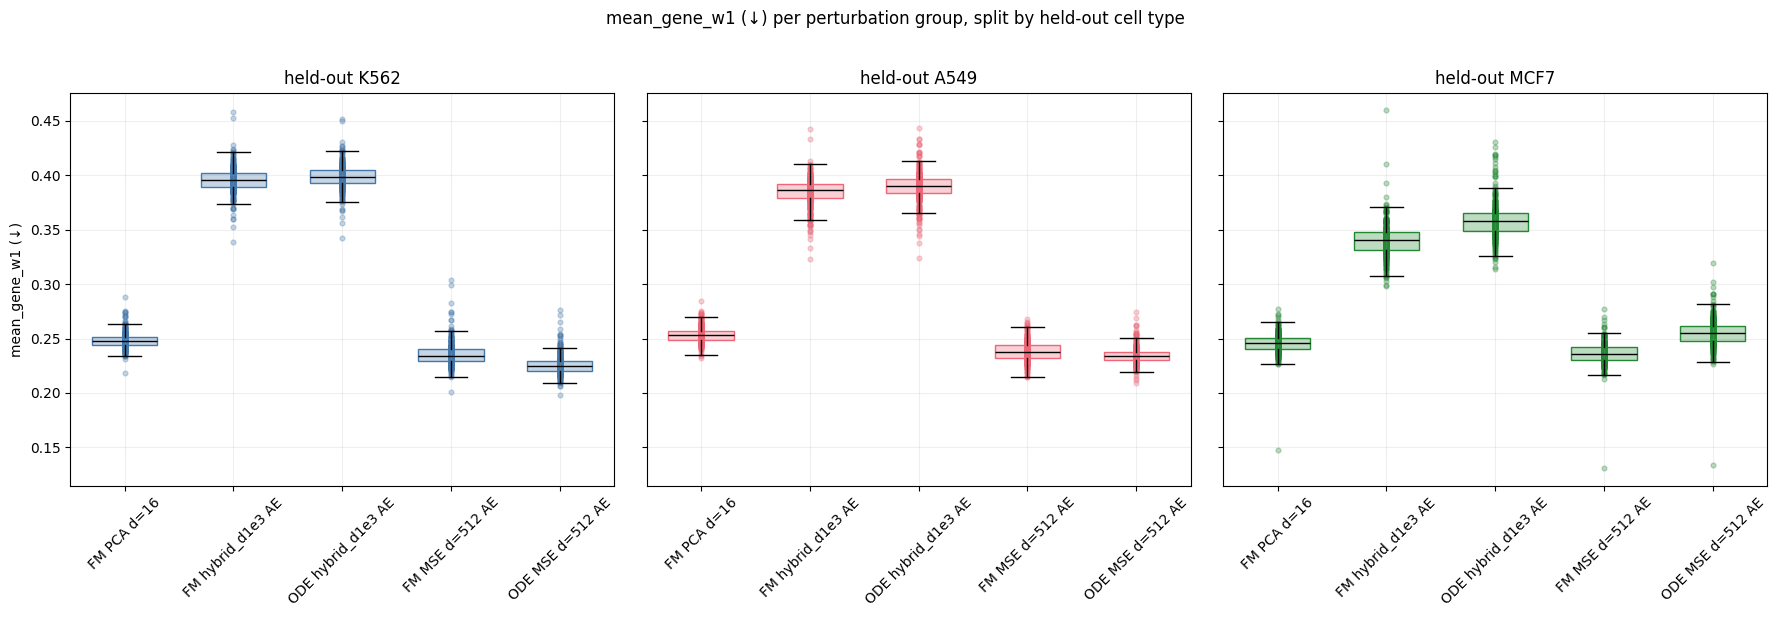

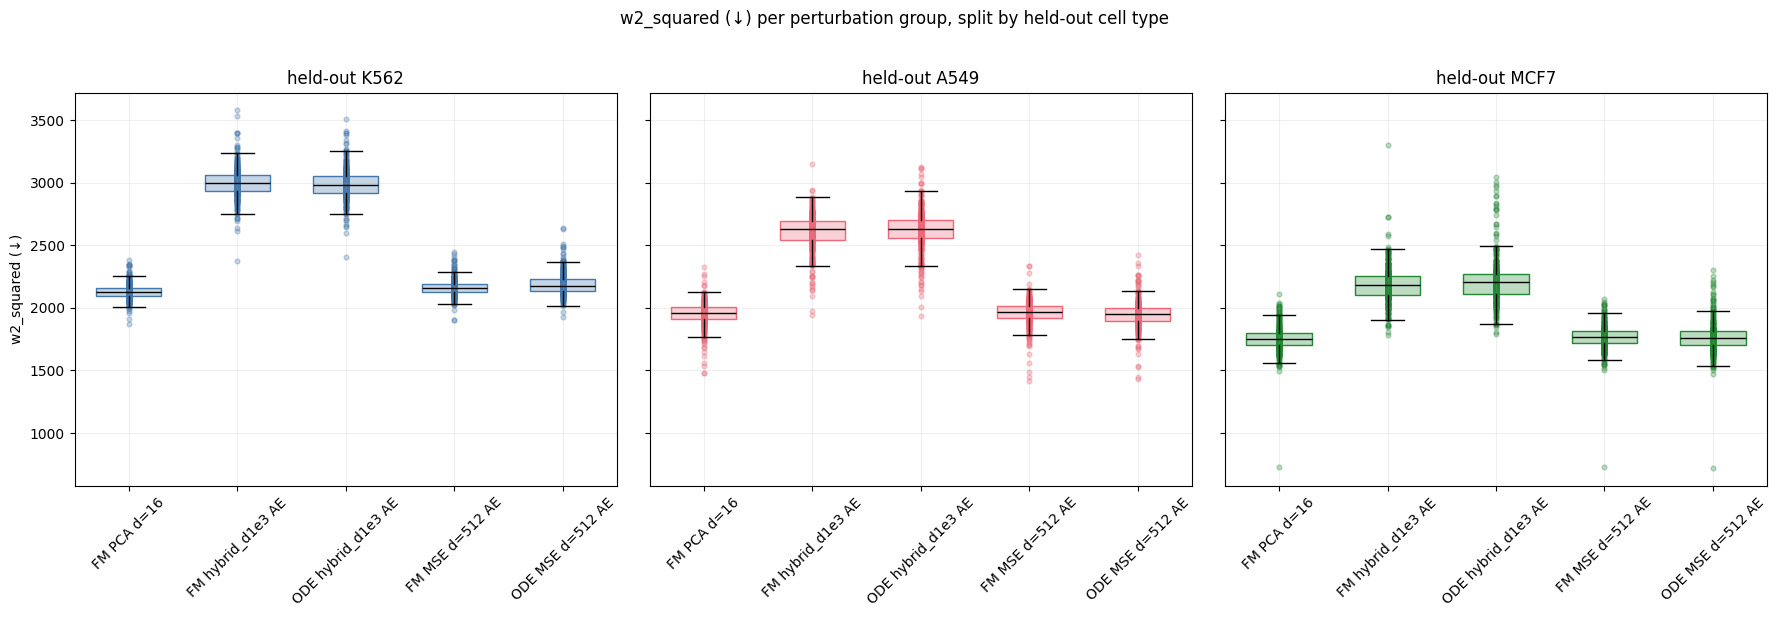

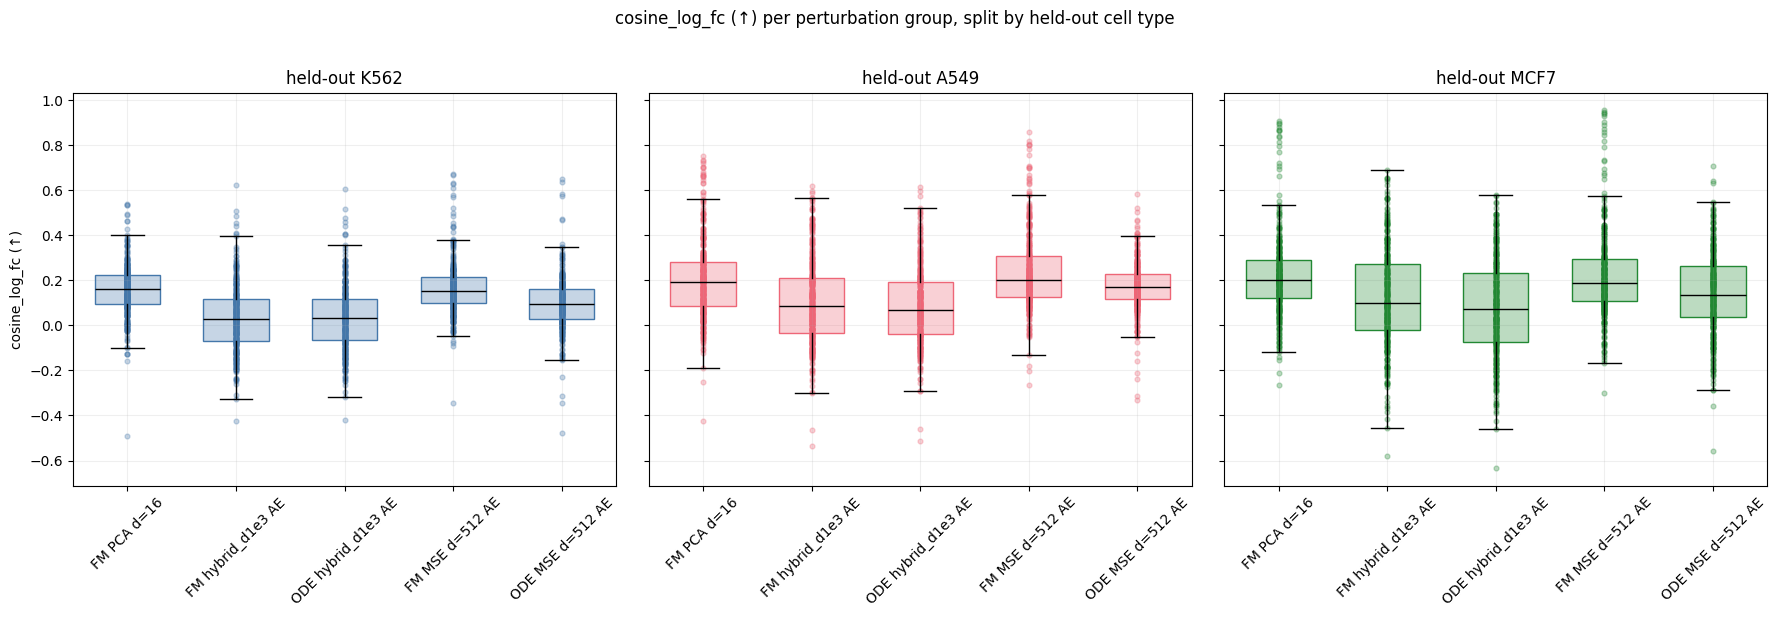

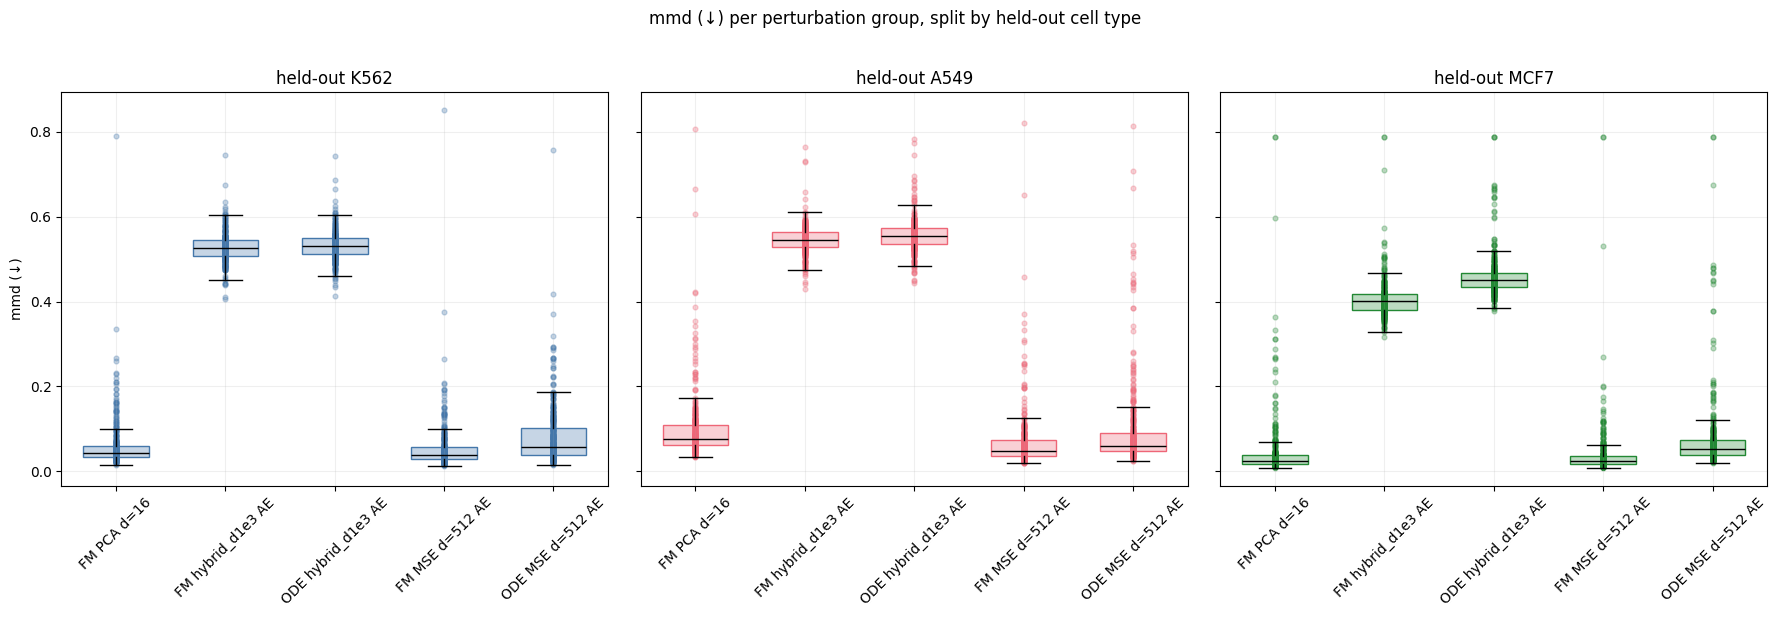

In [8]:
# per-group boxplots faceted by cell type (one row per metric, one column per CT)
for metric in metrics:
    sub = per_group[(per_group["metric_base"] == metric) | (per_group["metric"] == metric)]
    sub = sub.dropna(subset=["family", "splitter_ct"])
    if sub.empty:
        continue
    arrow = metric_arrow[metric]

    fig, axes = plt.subplots(1, len(CELL_TYPES), figsize=(6 * len(CELL_TYPES), 6), sharey=True)
    if len(CELL_TYPES) == 1:
        axes = [axes]
    families = list(MODELS.keys())
    for ax, ct in zip(axes, CELL_TYPES):
        ct_sub = sub[sub["splitter_ct"] == ct]
        data = [ct_sub.loc[ct_sub["family"] == f, "value"].dropna().to_numpy() for f in families]
        bp = ax.boxplot(data, labels=families, patch_artist=True, widths=0.6, showfliers=False)
        color = CT_COLORS[ct]
        for patch in bp["boxes"]:
            patch.set_facecolor((*[int(color[i : i + 2], 16) / 255 for i in (1, 3, 5)], 0.3))
            patch.set_edgecolor(color)
        for line in bp["medians"]:
            line.set_color("black")
        for idx, vals in enumerate(data, start=1):
            ax.scatter([idx] * len(vals), vals, s=12, alpha=0.3, color=color)
        ax.set_title(f"held-out {ct}")
        ax.tick_params(axis="x", rotation=45)
        ax.grid(alpha=0.2)
    axes[0].set_ylabel(f"{metric} ({arrow})")
    fig.suptitle(f"{metric} ({arrow}) per perturbation group, split by held-out cell type", y=1.02)
    plt.tight_layout()
    plt.show()
